# Ejercicio 1 — Cadenas de Markov y migración de ratings

**Máster Executive en Finanzas Cuantitativas 2026 · AFI Global Education**  
**Asignatura:** Fundamentos matemáticos — Procesos estocásticos

---

## Objetivo

A partir de la matriz anual de transición de ratings:

1. calcular la probabilidad acumulada de default y la probabilidad de primer default en cada año hasta 25 años;
2. agregar esas probabilidades para la cohorte de 5.002 compañías;
3. obtener la distribución de rating a 25 años y comprobarla mediante simulación.

La resolución comienza auditando el Excel, porque elevar una matriz de transición exige que sea cuadrada, estocástica y que el estado Default sea absorbente.


## Configuración, carga y auditoría del dato

Se leen los valores y las fórmulas del libro original. No se redondea la matriz: los cálculos usan toda la precisión almacenada en Excel.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from openpyxl import load_workbook
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titleweight": "bold",
})

DATA_PATH = Path("../0-enunciado/matriz-ratings.xlsx")
OUT = Path("resultados")
OUT.mkdir(exist_ok=True)

wb_formula = load_workbook(DATA_PATH, data_only=False)
wb_values = load_workbook(DATA_PATH, data_only=True)
ws_f = wb_formula["Hoja1"]
ws_v = wb_values["Hoja1"]

DESTINOS = [ws_v.cell(2, j).value for j in range(3, 11)]
ORIGENES = [ws_v.cell(i, 2).value for i in range(3, 12)]
Q = np.array(
    [[ws_v.cell(i, j).value for j in range(3, 11)] for i in range(3, 12)],
    dtype=float,
)
sumas_excel = np.array([ws_v.cell(i, 11).value for i in range(3, 12)], dtype=float)
formulas_suma = [ws_f.cell(i, 11).value for i in range(3, 12)]

# Controles estructurales del fichero fuente.
assert Q.shape == (9, 8)
assert ORIGENES == ["Aaa", "Aa", "A", "Baa", "Ba", "B", "Caa", "Ca-C", "Default"]
assert DESTINOS == ["Aaa", "Aa", "A", "Baa", "Ba", "B", "Caa-C", "Default"]
assert np.all(np.isfinite(Q)) and np.all((Q >= 0) & (Q <= 1))
assert np.allclose(Q.sum(axis=1), 1.0, atol=5e-15)
assert np.allclose(sumas_excel, 1.0, atol=5e-15)
assert np.array_equal(Q[-1], np.r_[np.zeros(7), 1.0])
assert all(isinstance(x, str) and "SUM" in x.upper() for x in formulas_suma)

print(f"Libro: {DATA_PATH.name} · hoja: {ws_v.title}")
print(f"Dimensión numérica leída: {Q.shape[0]} orígenes × {Q.shape[1]} destinos")
print(f"Máximo error de suma por fila: {np.max(np.abs(Q.sum(axis=1)-1)):.2e}")
print("Default es absorbente: sí")
display(pd.DataFrame(Q, index=ORIGENES, columns=DESTINOS))


Libro: matriz-ratings.xlsx · hoja: Hoja1
Dimensión numérica leída: 9 orígenes × 8 destinos
Máximo error de suma por fila: 2.22e-16
Default es absorbente: sí


,Aaa,Aa,A,Baa,Ba,B,Caa-C,Default
Aaa,8.239101e-01,1.335319e-01,4.232949e-02,2.284485e-04,1.029606e-07,4.904662e-12,3.892307e-16,5.216254e-22
Aa,3.261439e-01,5.813253e-01,7.670458e-02,1.579849e-02,2.765163e-05,4.816051e-08,8.977053e-12,2.311305e-16
A,1.670234e-02,1.782599e-01,5.425594e-01,2.417709e-01,2.064874e-02,5.845800e-05,2.496450e-07,9.945478e-12
Baa,4.955904e-05,9.007525e-03,3.903045e-01,3.406883e-01,2.360838e-01,2.382473e-02,4.143846e-05,2.153291e-07
Ba,1.032542e-07,1.421354e-04,1.481325e-02,9.253187e-02,6.335492e-01,2.460351e-01,1.280385e-02,1.244875e-04
B,1.502479e-11,1.416804e-07,2.340144e-04,1.838424e-02,1.176141e-01,3.514421e-01,5.061265e-01,6.198923e-03
Caa,2.373236e-16,1.457089e-11,1.554381e-07,5.921876e-05,5.967324e-03,1.205454e-01,5.182277e-01,3.552002e-01
Ca-C,4.762987e-22,5.958838e-16,2.742543e-11,1.020743e-07,2.903952e-04,8.363707e-03,2.286774e-01,7.626684e-01
Default,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


## Corrección de la estructura de la matriz

El Excel contiene nueve filas de origen, porque desdobla el tramo inferior en `Caa` y `Ca-C`, pero solo ocho columnas de destino, donde ambos aparecen agregados como `Caa-C`. El enunciado también utiliza `Caa-C` como un único estado en la distribución inicial.

Siguiendo la aclaración de la profesora, se elimina la fila `Ca-C` y se conserva la fila `Caa` como representativa del estado agregado `Caa-C`. Esta elección se documenta expresamente y permite construir una matriz homogénea $P$ de dimensión $8\times8$. No se estiman ponderaciones que el enunciado no proporciona.


In [2]:
ESTADOS = DESTINOS
RATINGS = ESTADOS[:-1]

# Convención autorizada: se conserva la fila Caa (Q[6]) y se elimina Ca-C (Q[7]).
P = np.vstack([Q[:7], Q[8]])
assert P.shape == (8, 8)
assert np.all(P >= 0)
assert np.allclose(P.sum(axis=1), 1.0, atol=5e-15)
assert np.array_equal(P[-1], np.r_[np.zeros(7), 1.0])
assert np.array_equal(P[6], Q[6])

print("Matriz anual corregida: fila Caa asignada al estado Caa-C")
display(pd.DataFrame(P, index=ESTADOS, columns=ESTADOS))


Matriz anual corregida: fila Caa asignada al estado Caa-C


,Aaa,Aa,A,Baa,Ba,B,Caa-C,Default
Aaa,8.239101e-01,1.335319e-01,4.232949e-02,0.000228,1.029606e-07,4.904662e-12,3.892307e-16,5.216254e-22
Aa,3.261439e-01,5.813253e-01,7.670458e-02,0.015798,2.765163e-05,4.816051e-08,8.977053e-12,2.311305e-16
A,1.670234e-02,1.782599e-01,5.425594e-01,0.241771,2.064874e-02,5.845800e-05,2.496450e-07,9.945478e-12
Baa,4.955904e-05,9.007525e-03,3.903045e-01,0.340688,2.360838e-01,2.382473e-02,4.143846e-05,2.153291e-07
Ba,1.032542e-07,1.421354e-04,1.481325e-02,0.092532,6.335492e-01,2.460351e-01,1.280385e-02,1.244875e-04
B,1.502479e-11,1.416804e-07,2.340144e-04,0.018384,1.176141e-01,3.514421e-01,5.061265e-01,6.198923e-03
Caa-C,2.373236e-16,1.457089e-11,1.554381e-07,0.000059,5.967324e-03,1.205454e-01,5.182277e-01,3.552002e-01
Default,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


---

## Apartado 1.a — Default acumulado y primer default por año

Para una compañía que parte del rating $i$, representado por el vector canónico $e_i$, la distribución al final del año $n\geq1$ es:

$$\pi_i(n)=e_i^{\top}P^n.$$

Como Default es absorbente, su componente es la probabilidad acumulada de haber hecho default antes o en $n$:

$$F_i(n)=\Pr(\tau_i\leq n)=\left[\pi_i(n)\right]_{D}.$$

La probabilidad de que el **primer** default ocurra exactamente en el año $n$ es la diferencia de acumuladas:

$$f_i(n)=\Pr(\tau_i=n)=F_i(n)-F_i(n-1),\qquad F_i(0)=0.$$

Esta diferencia es válida precisamente porque no se puede salir de Default.


In [3]:
HORIZONTE = 25
anios = np.arange(1, HORIZONTE + 1)

distribuciones = np.stack(
    [np.linalg.matrix_power(P, n)[:7] for n in anios],
    axis=0,
)  # (año, origen, destino)
pd_acumulada = distribuciones[:, :, -1].T
pd_exacta = np.diff(np.c_[np.zeros(len(RATINGS)), pd_acumulada], axis=1)

# Invariantes probabilísticos.
assert np.allclose(distribuciones.sum(axis=2), 1.0, atol=2e-14)
assert np.all(np.diff(pd_acumulada, axis=1) >= -2e-15)
assert np.all(pd_exacta >= -2e-15)
assert np.allclose(pd_exacta.sum(axis=1), pd_acumulada[:, -1], atol=2e-14)

resumen_1a = pd.DataFrame({
    "PD 1Y": pd_acumulada[:, 0],
    "PD 5Y": pd_acumulada[:, 4],
    "PD 10Y": pd_acumulada[:, 9],
    "PD 25Y": pd_acumulada[:, 24],
    "Año de máximo primer-default": 1 + np.argmax(pd_exacta, axis=1),
    "Máximo primer-default": np.max(pd_exacta, axis=1),
}, index=RATINGS)

print("Resumen por rating — matriz 8×8 corregida:")
display(resumen_1a.style.format({
    "PD 1Y": "{:.6%}", "PD 5Y": "{:.4%}", "PD 10Y": "{:.4%}",
    "PD 25Y": "{:.4%}", "Máximo primer-default": "{:.4%}",
}))

tabla_acumulada = pd.DataFrame(pd_acumulada.T, index=anios, columns=RATINGS)
tabla_acumulada.index.name = "Año"
tabla_exacta = pd.DataFrame(pd_exacta.T, index=anios, columns=RATINGS)
tabla_exacta.index.name = "Año"

print("\nProbabilidad acumulada de default F_i(n):")
display(tabla_acumulada.style.format("{:.4%}"))
print("Probabilidad de primer default exactamente en n, f_i(n):")
display(tabla_exacta.style.format("{:.4%}"))


Resumen por rating — matriz 8×8 corregida:

Probabilidad acumulada de default F_i(n):
Probabilidad de primer default exactamente en n, f_i(n):


,PD 1Y,PD 5Y,PD 10Y,PD 25Y,Año de máximo primer-default,Máximo primer-default
Aaa,0.000000%,0.0146%,1.0593%,15.2802%,25,1.1634%
Aa,0.000000%,0.0664%,1.8771%,17.5452%,24,1.1746%
A,0.000000%,1.0040%,10.1706%,35.4688%,11,2.2320%
Baa,0.000022%,5.1262%,22.5847%,51.1040%,8,3.6332%
Ba,0.012449%,20.9682%,51.6792%,78.2409%,5,7.9027%
B,0.619892%,55.9989%,79.2452%,92.4464%,2,18.1969%
Caa-C,35.520024%,79.4904%,91.9851%,97.6548%,1,35.5200%


,Aaa,Aa,A,Baa,Ba,B,Caa-C
Año,,,,,,,
1,0.0000%,0.0000%,0.0000%,0.0000%,0.0124%,0.6199%,35.5200%
2,0.0000%,0.0000%,0.0003%,0.0192%,0.6276%,18.8168%,54.0023%
3,0.0000%,0.0003%,0.0189%,0.6054%,5.7329%,34.6391%,65.7775%
4,0.0010%,0.0114%,0.2771%,2.3951%,13.0655%,46.7707%,73.8176%
5,0.0146%,0.0664%,1.0040%,5.1262%,20.9682%,55.9989%,79.4904%
6,0.0646%,0.2019%,2.2324%,8.4266%,28.5815%,63.0931%,83.5900%
7,0.1766%,0.4436%,3.8795%,11.9983%,35.5265%,68.6176%,86.6153%
8,0.3717%,0.8036%,5.8253%,15.6315%,41.6793%,72.9732%,88.8907%
9,0.6637%,1.2833%,7.9542%,19.1885%,47.0433%,76.4465%,90.6319%


,Aaa,Aa,A,Baa,Ba,B,Caa-C
Año,,,,,,,
1,0.0000%,0.0000%,0.0000%,0.0000%,0.0124%,0.6199%,35.5200%
2,0.0000%,0.0000%,0.0003%,0.0192%,0.6152%,18.1969%,18.4823%
3,0.0000%,0.0003%,0.0186%,0.5862%,5.1053%,15.8222%,11.7752%
4,0.0010%,0.0110%,0.2582%,1.7897%,7.3326%,12.1316%,8.0401%
5,0.0136%,0.0550%,0.7269%,2.7311%,7.9027%,9.2282%,5.6729%
6,0.0500%,0.1355%,1.2284%,3.3004%,7.6133%,7.0942%,4.0996%
7,0.1120%,0.2417%,1.6471%,3.5717%,6.9450%,5.5245%,3.0253%
8,0.1951%,0.3600%,1.9458%,3.6332%,6.1529%,4.3556%,2.2754%
9,0.2920%,0.4797%,2.1289%,3.5570%,5.3640%,3.4733%,1.7412%


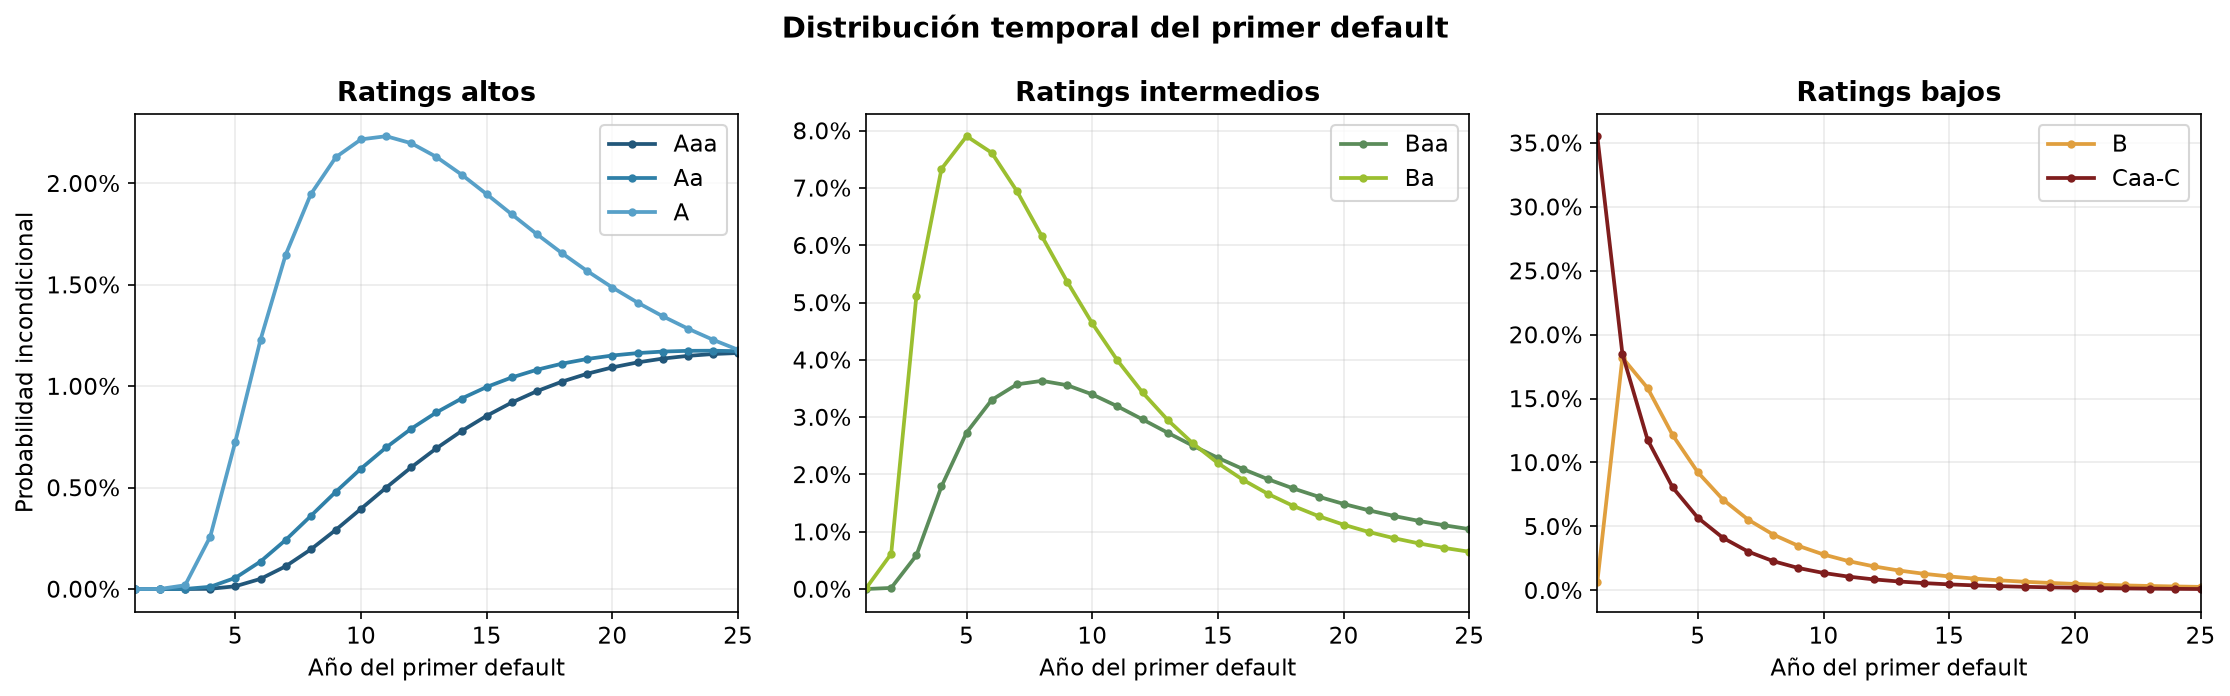

In [4]:
grupos = [
    ("Ratings altos", ["Aaa", "Aa", "A"]),
    ("Ratings intermedios", ["Baa", "Ba"]),
    ("Ratings bajos", ["B", "Caa-C"]),
]
colores = {
    "Aaa": "#22577a", "Aa": "#2f80a8", "A": "#57a0c8",
    "Baa": "#5b8c5a", "Ba": "#9bbf30",
    "B": "#e09f3e", "Caa-C": "#7f1d1d",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.7), sharex=True)
for ax, (titulo, nombres) in zip(axes, grupos):
    for nombre in nombres:
        i = RATINGS.index(nombre)
        ax.plot(anios, pd_exacta[i], marker="o", ms=3, lw=1.8,
                color=colores[nombre], label=nombre)
    ax.set(title=titulo, xlabel="Año del primer default", xlim=(1, 25))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend()
axes[0].set_ylabel("Probabilidad incondicional")
fig.suptitle("Distribución temporal del primer default",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT / "grafico_1a_primer_default_ratings.png", dpi=150, bbox_inches="tight")
plt.show()


**Lectura de las formas.** En los ratings altos la masa de default tarda en acumularse y el máximo **observado** puede quedar en el último año representado; en ese caso solo sabemos que la curva sigue creciendo dentro de la ventana de 25 años, no que ese sea su máximo global. En los intermedios aparece una joroba en años centrales; en los bajos domina el riesgo inmediato y la curva cae con rapidez. No son tasas hazard condicionadas a supervivencia: son probabilidades incondicionales de primer default.


---

## Apartado 1.b — Cohorte de 5.002 compañías

La distribución inicial agregada es el vector fila:

$$p_0=\frac{1}{5002}(136,694,1298,1175,578,817,304,0).$$

Para la cohorte, $p_n=p_0P^n$. La proporción esperada que hace primer default en el año $n$ vuelve a ser la diferencia entre las componentes Default de $p_n$ y $p_{n-1}$.


In [5]:
CONTEOS = np.array([136, 694, 1298, 1175, 578, 817, 304, 0], dtype=float)
TOTAL = int(CONTEOS.sum())
assert TOTAL == 5_002
p0 = CONTEOS / TOTAL

cohorte_dist = np.array([p0 @ np.linalg.matrix_power(P, n) for n in anios])
cohorte_acum = cohorte_dist[:, -1]
cohorte_exacta = np.diff(np.r_[0.0, cohorte_acum])
cohorte_n = TOTAL * cohorte_exacta

assert np.allclose(cohorte_dist.sum(axis=1), 1.0, atol=2e-14)
assert np.all(cohorte_exacta >= -2e-15)
assert np.isclose(cohorte_exacta.sum(), cohorte_acum[-1])

tabla_cohorte = pd.DataFrame({
    "Proporción default exacto": cohorte_exacta,
    "Compañías esperadas": cohorte_n,
    "PD acumulada": cohorte_acum,
}, index=anios)
tabla_cohorte.index.name = "Año"

display(tabla_cohorte.style.format({
    "Proporción default exacto": "{:.4%}",
    "Compañías esperadas": "{:.2f}",
    "PD acumulada": "{:.4%}",
}))
print(f"Año modal del primer default: {1 + np.argmax(cohorte_exacta)}")
print(f"Defaults esperados hasta 25Y: {TOTAL*cohorte_acum[-1]:.2f} "
      f"({cohorte_acum[-1]:.4%} de la cohorte)")


Año modal del primer default: 2
Defaults esperados hasta 25Y: 2707.79 (54.1342% de la cohorte)


,Proporción default exacto,Compañías esperadas,PD acumulada
Año,,,
1,2.2614%,113.12,2.2614%
2,4.1711%,208.64,6.4326%
3,4.0325%,201.70,10.4651%
4,3.8064%,190.40,14.2715%
5,3.6034%,180.24,17.8749%
6,3.4019%,170.16,21.2768%
7,3.1917%,159.65,24.4685%
8,2.9743%,148.78,27.4428%
9,2.7554%,137.83,30.1983%


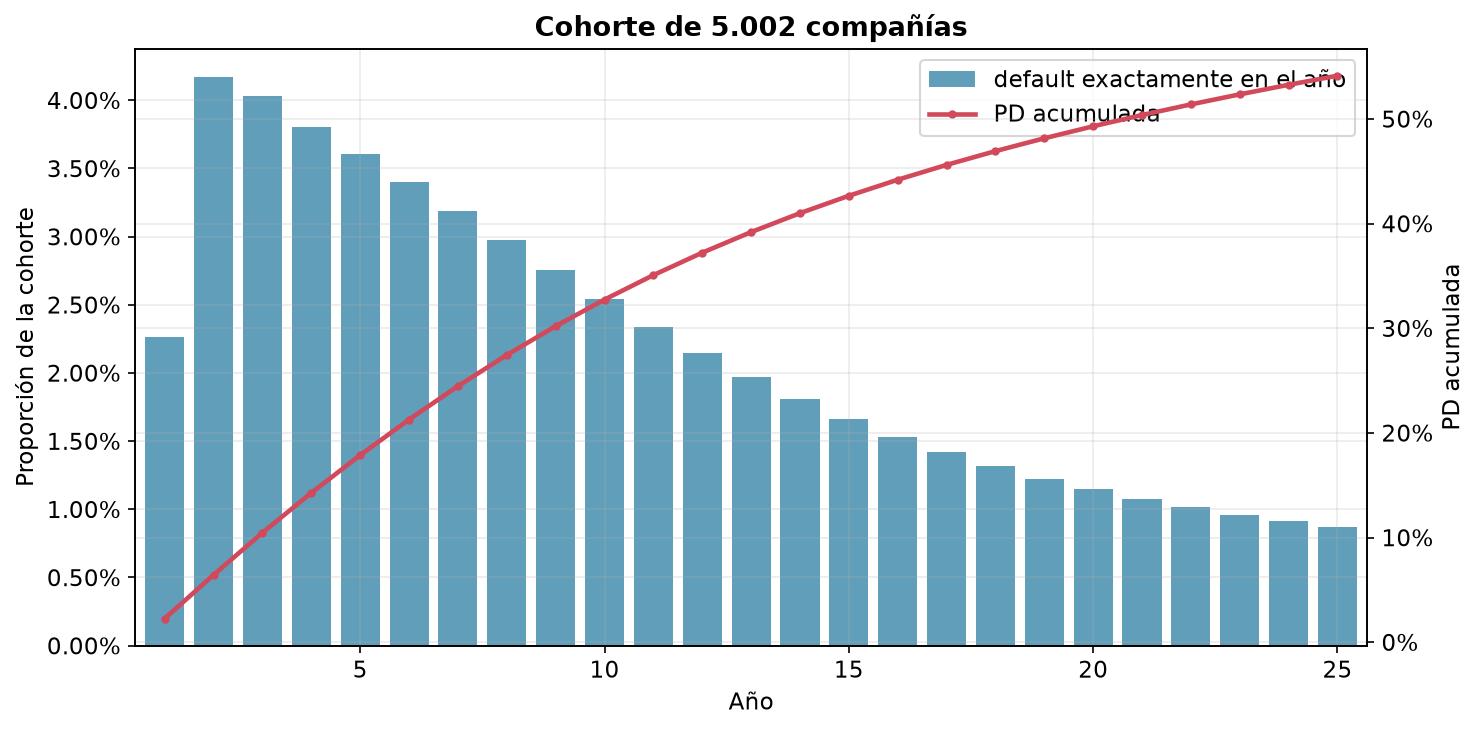

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(anios, cohorte_exacta, color="#3a86a8", alpha=0.8,
        label="default exactamente en el año")
ax1.set(xlabel="Año", ylabel="Proporción de la cohorte", xlim=(0.4, 25.6))
ax1.yaxis.set_major_formatter(PercentFormatter(1))
ax2 = ax1.twinx()
ax2.plot(anios, cohorte_acum, color="#d1495b", lw=2.2, marker="o", ms=3,
         label="PD acumulada")
ax2.set_ylabel("PD acumulada")
ax2.yaxis.set_major_formatter(PercentFormatter(1))
lineas = ax1.get_legend_handles_labels()
lineas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas[0] + lineas2[0], lineas[1] + lineas2[1], loc="upper right")
ax1.set_title("Cohorte de 5.002 compañías")
fig.tight_layout()
fig.savefig(OUT / "grafico_1b_cohorte_default.png", dpi=150, bbox_inches="tight")
plt.show()


### Convención aplicada al tramo Caa-C

La fila `Ca-C` del fichero fuente no se utiliza. La fila `Caa` se renombra `Caa-C` y representa íntegramente ese estado en todos los cálculos. Esta es una convención permitida expresamente por la profesora ante la ausencia de ponderaciones para agregar ambas filas.


In [7]:
# Control explícito de que la convención documentada es la que ejecuta el modelo.
assert np.array_equal(P[6], Q[ORIGENES.index("Caa")])
assert not np.array_equal(P[6], Q[ORIGENES.index("Ca-C")])
print("Convención Caa-C verificada: se usa la fila Caa y se descarta Ca-C.")


Convención Caa-C verificada: se usa la fila Caa y se descarta Ca-C.


---

## Apartado 1.c — Distribución de rating a 25 años

Para los siete ratings iniciales presentes en la cohorte agregada, la distribución exacta es cada fila de $P^{25}$. La simulación genera 300.000 compañías por rating y aplica 25 transiciones categóricas independientes.

En cada paso se conserva una copia del estado anterior. Esto evita el error sutil de migrar dos veces a una misma compañía dentro del mismo año al actualizar los estados secuencialmente.


In [8]:
P25 = np.linalg.matrix_power(P, 25)
analitica_25 = P25[:7]
tabla_P25 = pd.DataFrame(analitica_25, index=RATINGS, columns=ESTADOS)

assert np.allclose(P25.sum(axis=1), 1.0, atol=3e-14)
assert np.all(P25 >= -2e-15)

print("Distribución analítica a 25 años — filas: rating inicial")
display(tabla_P25.style.format("{:.4%}"))


Distribución analítica a 25 años — filas: rating inicial


,Aaa,Aa,A,Baa,Ba,B,Caa-C,Default
Aaa,37.5273%,17.8215%,11.9252%,5.7768%,5.5144%,2.9272%,3.2274%,15.2802%
Aa,36.3420%,17.2849%,11.6103%,5.6414%,5.4332%,2.9075%,3.2355%,17.5452%
A,27.2730%,13.1386%,9.1075%,4.5350%,4.6774%,2.6540%,3.1458%,35.4688%
Baa,20.0082%,9.7333%,6.9067%,3.5003%,3.7822%,2.2268%,2.7384%,51.1040%
Ba,8.1363%,4.0673%,3.0722%,1.6281%,1.9602%,1.2478%,1.6472%,78.2409%
B,2.6676%,1.3566%,1.0639%,0.5783%,0.7368%,0.4870%,0.6635%,92.4464%
Caa-C,0.7695%,0.4004%,0.3291%,0.1843%,0.2498%,0.1714%,0.2406%,97.6548%


In [9]:
N_SIM = 300_000
rng = np.random.default_rng(20260902)
cdf = np.cumsum(P, axis=1)
cdf[:, -1] = 1.0  # protege frente a redondeos en searchsorted

def simular_25_anios(estado_inicial):
    estados = np.full(N_SIM, estado_inicial, dtype=np.int8)
    for _ in range(25):
        anteriores = estados.copy()
        for estado in range(len(ESTADOS)):
            idx = np.flatnonzero(anteriores == estado)
            if idx.size:
                estados[idx] = np.searchsorted(
                    cdf[estado], rng.random(idx.size), side="right"
                )
    return np.bincount(estados, minlength=len(ESTADOS)) / N_SIM

simulada_25 = np.vstack([simular_25_anios(i) for i in range(7)])
error_25 = simulada_25 - analitica_25
se_25 = np.sqrt(np.maximum(
    analitica_25 * (1.0 - analitica_25) / N_SIM,
    1.0 / N_SIM**2,
))
z_25 = error_25 / se_25

# Gate estadístico celda a celda: error dentro de 4 SE, con holgura discreta.
tolerancia = 4.0 * se_25 + 5.0 / N_SIM
assert np.all(np.abs(error_25) <= tolerancia)

validacion = pd.DataFrame({
    "PD 25Y analítica": analitica_25[:, -1],
    "PD 25Y simulada": simulada_25[:, -1],
    "Error (pp)": 100 * error_25[:, -1],
}, index=RATINGS)
display(validacion.style.format({
    "PD 25Y analítica": "{:.4%}",
    "PD 25Y simulada": "{:.4%}",
    "Error (pp)": "{:+.4f}",
}))
print(f"Máximo error absoluto en las 56 celdas: {np.max(np.abs(error_25)):.6f}")
print(f"Máximo error estandarizado: {np.max(np.abs(z_25)):.2f} SE")

cohorte_25_analitica = p0 @ P25
cohorte_25_simulada = p0[:7] @ simulada_25
comparacion_cohorte = pd.DataFrame({
    "Analítica": cohorte_25_analitica,
    "Simulación ponderada": cohorte_25_simulada,
    "Error": cohorte_25_simulada - cohorte_25_analitica,
}, index=ESTADOS)
print("\nCompañía elegida al azar de la cohorte — distribución a 25 años:")
display(comparacion_cohorte.style.format("{:.4%}"))


Máximo error absoluto en las 56 celdas: 0.001486
Máximo error estandarizado: 2.41 SE

Compañía elegida al azar de la cohorte — distribución a 25 años:


,PD 25Y analítica,PD 25Y simulada,Error (pp)
Aaa,15.2802%,15.2990%,+0.0188
Aa,17.5452%,17.5450%,-0.0002
A,35.4688%,35.5270%,+0.0582
Baa,51.1040%,50.9987%,-0.1054
Ba,78.2409%,78.1350%,-0.1059
B,92.4464%,92.3980%,-0.0484
Caa-C,97.6548%,97.6837%,+0.0289


,Analítica,Simulación ponderada,Error
Aaa,19.2625%,19.2893%,0.0268%
Aa,9.2945%,9.2679%,-0.0266%
A,6.4697%,6.4897%,0.0200%
Baa,3.2326%,3.2164%,-0.0162%
Ba,3.3680%,3.3903%,0.0223%
B,1.9289%,1.9453%,0.0164%
Caa-C,2.3096%,2.2944%,-0.0152%
Default,54.1342%,54.1066%,-0.0276%


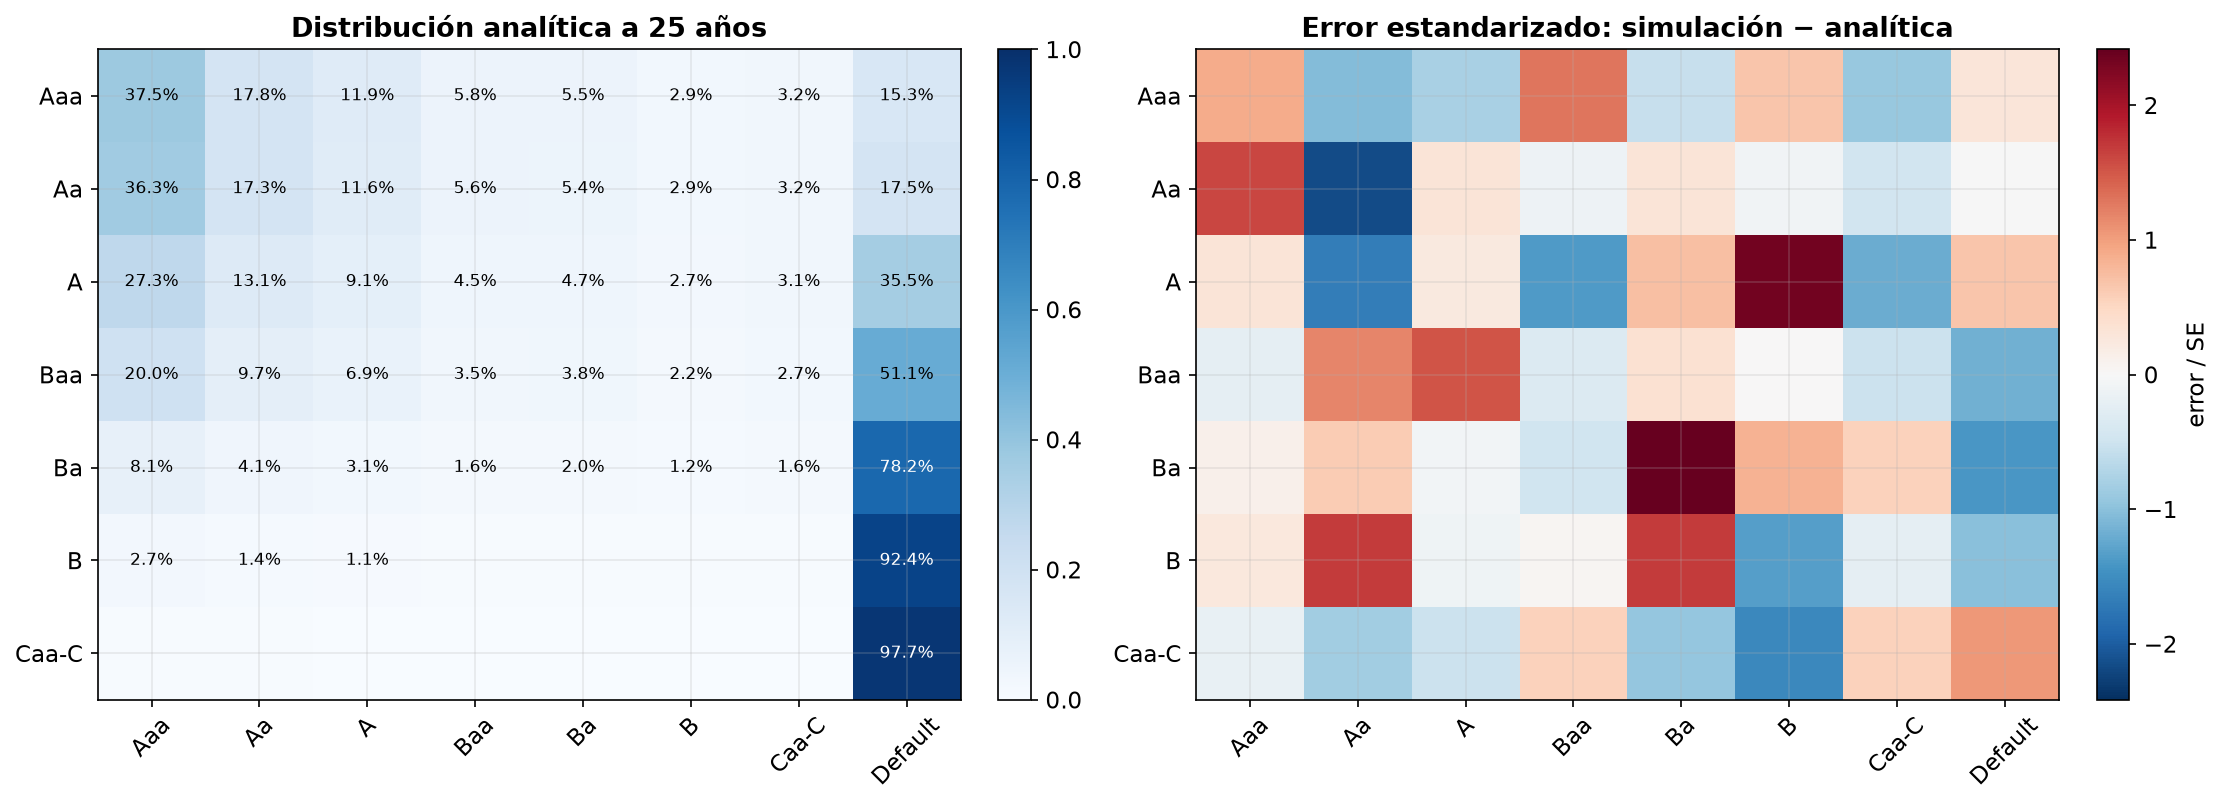

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

im0 = axes[0].imshow(analitica_25, cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[0].set(title="Distribución analítica a 25 años",
            xticks=range(8), xticklabels=ESTADOS,
            yticks=range(7), yticklabels=RATINGS)
axes[0].tick_params(axis="x", rotation=45)
for i in range(7):
    for j in range(8):
        if analitica_25[i, j] >= 0.01:
            axes[0].text(j, i, f"{analitica_25[i,j]:.1%}",
                         ha="center", va="center",
                         color="white" if analitica_25[i,j] > 0.55 else "black",
                         fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

vmax_z = np.max(np.abs(z_25))
im1 = axes[1].imshow(z_25, cmap="RdBu_r", vmin=-vmax_z, vmax=vmax_z, aspect="auto")
axes[1].set(title="Error estandarizado: simulación − analítica",
            xticks=range(8), xticklabels=ESTADOS,
            yticks=range(7), yticklabels=RATINGS)
axes[1].tick_params(axis="x", rotation=45)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="error / SE")

fig.tight_layout()
fig.savefig(OUT / "grafico_1c_distribucion_25y_validacion.png",
            dpi=150, bbox_inches="tight")
plt.show()


---

## Conclusiones

- La potencia de una matriz de transición da la distribución multi-periodo; la diferencia de PD acumuladas da la distribución del tiempo de primer default.
- Las curvas separan claramente los tres regímenes: riesgo tardío en ratings altos, joroba intermedia y fuerte masa inicial en ratings bajos.
- La simulación reproduce $P^{25}$ dentro del error Monte Carlo esperado.
- La matriz se cierra en ocho estados conservando la fila `Caa` como representante de `Caa-C`, de acuerdo con la convención permitida por la profesora.


In [11]:
print("=" * 78)
print("RESUMEN EJERCICIO 1 · MATRIZ 8×8 CORREGIDA")
print("=" * 78)
print(f"Cohorte — default exacto 1Y: {cohorte_exacta[0]:.4%} "
      f"({TOTAL*cohorte_exacta[0]:.2f} compañías esperadas)")
print(f"Cohorte — PD acumulada 25Y: {cohorte_acum[-1]:.4%} "
      f"({TOTAL*cohorte_acum[-1]:.2f} compañías esperadas)")
print("Convención Caa-C: fila Caa conservada; fila Ca-C eliminada")
print(f"Validación P^25 — máximo error: {np.max(np.abs(error_25)):.6f}; "
      f"máximo |z|: {np.max(np.abs(z_25)):.2f}")


RESUMEN EJERCICIO 1 · MATRIZ 8×8 CORREGIDA
Cohorte — default exacto 1Y: 2.2614% (113.12 compañías esperadas)
Cohorte — PD acumulada 25Y: 54.1342% (2707.79 compañías esperadas)
Convención Caa-C: fila Caa conservada; fila Ca-C eliminada
Validación P^25 — máximo error: 0.001486; máximo |z|: 2.41
